# Random Forest Analysis of Aerosol Optical Properties

## Overview

This notebook applies Random Forest regression to investigate the relationships between aerosol physicochemical properties and aerosol optical properties measured during the SAMBBA aircraft campaign. The analysis quantifies the relative importance of each predictor, evaluates model performance, and examines the Partial Dependence Profiles (PDPs) of the most influential variables to support the physical interpretation of the models.

## Workflow

1. Load and synchronize the processed SAMBBA datasets.
2. Merge all research flights into a single quality-controlled dataset.
3. Configure and train Random Forest regression models.
4. Evaluate model performance using an independent test dataset.
5. Rank predictor variables according to their feature importance.
6. Generate publication-quality feature importance figures and export the model performance metrics.
7. Compute and visualize Partial Dependence Profiles (PDPs) for the most influential predictors.

## Inputs

- Harmonized SAMBBA datasets generated during the preprocessing stage.
- Aerosol chemical composition, optical properties, aircraft position, and ancillary variables from the selected research flights.

## Outputs

- Random Forest regression models for the selected target variables.
- Feature importance plots.
- CSV tables containing model performance metrics.
- Publication-quality Partial Dependence Profile (PDP) figures for the most influential predictors.

## Requirements

This notebook assumes that the preprocessing workflow has already been completed and that the harmonized SAMBBA datasets are available following the repository directory structure.

In [1]:
# Import the libraries required for data processing, statistical analysis and visualization.
import re
import numpy as np
import xarray as xr
import pandas as pd
from flights_io_commented  import get_matched_flights
from flight_processing_commented import process_flight
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
# Define the location of the SAMBBA flight archive and identify the flights to be included in the analysis.

base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

dirs =  [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

flights = get_matched_flights(base_dir, dirs)

for flight in flights:
    print(flight.core_cloud)

Matched flights: 10
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b742.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/core_processed/core-cloud-phy_faam_20120927_v500_r0_b743.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b744.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/core_processed/core-cloud-phy_faam_20120928_v500_r0_b745.nc
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2

In [3]:
# Process each research flight individually, synchronize measurements from the different 
# instruments and store the variables required for the combined analysis.
results = []

for flight in flights:
    out = process_flight(flight)

    # Retain only the timestamps shared by the FAAM core, AMS and SP2
    # datasets. Restricting the analysis to concurrent measurements
    # ensures that all variables describe the same atmospheric conditions.
    common_times = np.intersect1d(out.core.data_point.values, out.ams.time.values)
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, out.sp2.time.values)
    
    
    core_file_matched = out.core.sel(data_point=common_times)
    ams_resampled_matched = out.ams.sel(time=common_times)
    sp2_resampled_matched = out.sp2.sel(time=common_times)
    resampled_neph_matched = out.neph.sel(time=common_times)
    Dg_aligned_matched = out.Dgs.reindex(pd.to_datetime(common_times), method="nearest")
    PM_ratio_matched = out.PM_ratio.sel(PCAS2TSPM = common_times)
    
    # Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()

    # Cabin conditions
    CAB_PRES = core_file_matched["CAB_PRES"].values.squeeze()      # hPa
    CAB_TEMP = core_file_matched["CAB_TEMP"].values.squeeze() + 273.15  # K

    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()

    # STP reference
    P_STP = 1013.25   # hPa
    T_STP = 273.15    # K

    conversion_factor = (CAB_PRES / P_STP) * (T_STP / CAB_TEMP)

    #Sp2 file variables
    BC = sp2_resampled_matched.values * conversion_factor  # Convert to ATP conditions
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values * conversion_factor  # Convert to ATP conditions
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    SO4 = ams_resampled_matched['SO4'].values * conversion_factor  # Convert to ATP conditions
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NH4 = ams_resampled_matched['NH4'].values * conversion_factor  # Convert to ATP conditions
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    NO3 = ams_resampled_matched['NO3'].values * conversion_factor  # Convert to ATP conditions
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values * conversion_factor  # Convert to ATP conditions
    AS = ams_resampled_matched['NH4_2SO4'].values * conversion_factor  # Convert to ATP conditions
    AN = ams_resampled_matched['NH4NO3'].values * conversion_factor  # Convert to ATP conditions
    #PCASP variables
    Dg = Dg_aligned_matched
    ratio_pm = PM_ratio_matched
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', flight.core)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    results.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'Exctinction': PSAP_matched+TSC_green,
        'ABS_PSAP':PSAP_matched,
        'DG_aligned': Dg,
        'PM_ratio': ratio_pm,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'flight': flight_number
    })

In [4]:
# Merge the processed observations from all flights into a single DataFrame for the statistical analyses.
# Combine all flight data
combined_data = []
for entry in results:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'ABS_PSAP':entry['ABS_PSAP'],
            'rBC': entry['BC'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'AS': entry['AS'],
            'AN': entry['AN'],
            'OA': entry['ORG'],
            'DG': entry['DG_aligned'],
            'PM_coarse': entry['PM_ratio'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Ext': entry['Exctinction'],
            'Flight': entry['flight']
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
df_clean = df_all.replace([np.inf, -np.inf], np.nan).dropna()

In [5]:
# Define publication-style labels for the optical variables. These
# labels are used automatically in the figures generated throughout
# the Random Forest analysis.
target_labels = {
    "Ext": r"$\sigma_{ext}$",
    "TSC_green": r"$\sigma_{sca,\,green}$",
    "TSC_blue": r"$\sigma_{sca,\,blue}$",
    "TSC_red": r"$\sigma_{sca,\,red}$",
    "ABS_PSAP": r"$\sigma_{abs}$",
}

In [6]:
def run_random_forest(
    df,
    target_variable,
    model_type="reduced",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
):
    """
    Train and evaluate a Random Forest model.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    target_variable : str
        Name of the variable to be predicted.
    model_type : {"full", "reduced"}, default="reduced"
        Feature set used for the model.
    test_size : float, default=0.2
        Fraction of the dataset used for testing.
    random_state : int, default=42
        Random seed.
    n_estimators : int, default=600
        Number of trees in the Random Forest.

    Returns
    -------
    top_features : pandas.Series
        Feature importance ranked in descending order.
    r2 : float
        Coefficient of determination.
    rmse : float
        Root Mean Square Error.
    features : pandas.DataFrame
        Predictor variables.
    X_train : pandas.DataFrame
        Training predictors.
    X_test : pandas.DataFrame
        Testing predictors.
    target_name : str
        Publication-style name of the predicted variable.
    """

    # Define the predictor sets used in the two Random Forest
    # configurations evaluated in this study.
    full_drop = [
        "Ext", "TSC_green", "TSC_blue", "TSC_red",
        "Flight", "ABS_PSAP", "DG", "AS", "AN"
    ]

    reduced_drop = full_drop + [
        "LAT", "LON", "ALT", "CO"
    ]

    drop_columns = {
        "full": full_drop,
        "reduced": reduced_drop,
    }

    # Build the predictor matrix while automatically excluding the
    # selected target variable.
    features = df.drop(
        columns=list(set(drop_columns[model_type] + [target_variable]))
    )

    # Convert optical coefficients from m⁻¹ to Mm⁻¹ to maintain
    # consistency with the units used throughout the manuscript.
    optical_targets = [
        "Ext",
        "TSC_blue",
        "TSC_green",
        "TSC_red",
        "ABS_PSAP",
    ]

    if target_variable in optical_targets:
        target = df[target_variable] * 1e6
    else:
        target = df[target_variable]

    # Retrieve the publication-style label associated with the selected
    # target variable.
    target_name = target_labels.get(target_variable, target_variable)

    # Split the observations into independent training and testing
    # subsets for model evaluation.
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=random_state,
    )

    # Train the Random Forest regression model.
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)

    # Evaluate the model performance using the independent test dataset.
    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Rank the predictor variables according to their relative importance
    # in the fitted Random Forest model.
    top_features = (
        pd.Series(rf.feature_importances_, index=features.columns)
        .sort_values(ascending=False)
    )

    return (
        rf,
        top_features,
        r2,
        rmse,
        features,
        X_train,
        X_test,
        target_name,
    )

In [7]:
def plot_rf_importances_and_export_metrics(
    top_features,
    r2,
    rmse,
    features,
    df_clean,
    X_train,
    X_test,
    target_name,
    csv_path="rf_metrics.csv",
    figsize=(7, 4),
    label_fs=13,
    tick_fs=11
):
    """
    Generate a publication-quality feature importance plot and export the
    Random Forest performance metrics to a CSV file.

    Parameters
    ----------
    top_features : pandas.Series
        Feature importance values sorted in descending order.

    r2 : float
        Coefficient of determination.

    rmse : float
        Root Mean Square Error.

    features : pandas.DataFrame
        Predictor variables used to train the Random Forest model.

    df_clean : pandas.DataFrame
        Quality-controlled dataset used in the analysis.

    X_train, X_test : pandas.DataFrame
        Training and testing predictor matrices.

    target_name : str
        Publication-style label of the predicted variable.

    csv_path : str, optional
        Output path for the exported metrics table.

    Returns
    -------
    pandas.DataFrame
        Table containing the model performance metrics.
    """

    # ---------------------------------------------------------
    # Generate the feature importance plot.
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    top_features.plot(
        kind="bar",
        ax=ax,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_ylabel(
        f"Feature Importances ({target_name})",
        fontsize=label_fs
    )

    ax.set_xlabel("", fontsize=label_fs)

    ax.tick_params(
        axis="x",
        labelsize=tick_fs,
        rotation=45
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_fs
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Compile the model performance metrics into a table that
    # can be directly exported for reporting and manuscript
    # preparation.
    # ---------------------------------------------------------
    metrics_df = pd.DataFrame({
        "Metric": [
            "R2",
            "RMSE",
            "n_features",
            "n_measurements",
            "Train size",
            "Test size",
        ],
        "Value": [
            float(r2),
            float(rmse),
            int(features.shape[1]),
            int(len(df_clean)),
            int(len(X_train)),
            int(len(X_test)),
        ]
    })

    # Export the metrics table as a CSV file.
    metrics_df.to_csv(
        csv_path,
        index=False
    )

    return metrics_df

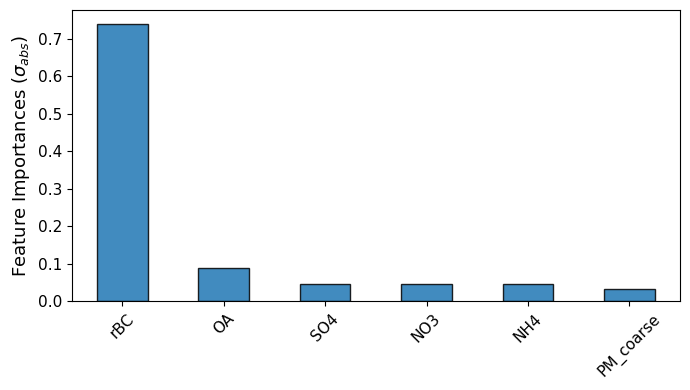

In [20]:
# Train and evaluate the Random Forest model using the selected target
# variable and predictor configuration.
(
    rf,
    top_features,
    r2,
    rmse,
    features,
    X_train,
    X_test,
    target_name,
) = run_random_forest(
    df=df_clean,
    target_variable="ABS_PSAP",      # e.g. "Ext", "TSC_green", "ABS_PSAP"
    model_type="reduced",       # Options: "full" or "reduced"
)

# Generate the feature importance figure and export the corresponding
# model performance metrics.
metrics_df = plot_rf_importances_and_export_metrics(
    top_features=top_features,
    r2=r2,
    rmse=rmse,
    features=features,
    df_clean=df_clean,
    X_train=X_train,
    X_test=X_test,
    target_name=target_name,
    csv_path="rf_abs_red_metrics.csv",
)

In [27]:
def plot_manual_pdp_top2_combined_figure(
    rf,
    X_train,
    feat_importances,
    target_name,
    unit_str="(Mm⁻¹)",
    n_grid=60,
    figsize=(16, 10),
    label_fs=14,
    tick_fs=11,
    legend_fs=15,
    title_fs=14,
    line_width=3,
    panel_label_fs=18
):
    """
    Create ONE figure containing 4 panels:

        a) Top-1 feature — Full PDP
        b) Top-1 feature — Zoomed PDP
        c) Top-2 feature — Full PDP
        d) Top-2 feature — Zoomed PDP

    Layout:
    --------
        [ a ] [ b ]
        [ c ] [ d ]

    Zoomed plots are on the right column.

    Includes:
    ----------
    - 5th/95th percentile lines
    - Weighted linear regression
    - Slope uncertainty propagation
    - Panel labels (a,b,c,d)

    Returns
    -------
    fig, axes, results_dict
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ======================================================
    # PDP computation
    # ======================================================
    def compute_manual_pdp(
        rf,
        X_train,
        feat,
        n_grid=60
    ):

        feat_values = X_train[feat].dropna()

        if feat_values.empty:
            return None

        grid = np.linspace(
            feat_values.min(),
            feat_values.max(),
            n_grid
        )

        p05 = np.percentile(feat_values, 5)
        p95 = np.percentile(feat_values, 95)

        pdp_mean = []
        pdp_std = []

        for val in grid:

            X_temp = X_train.copy()

            X_temp[feat] = val

            preds = rf.predict(X_temp)

            pdp_mean.append(np.mean(preds))
            pdp_std.append(np.std(preds))

        return (
            grid,
            np.asarray(pdp_mean),
            np.asarray(pdp_std),
            p05,
            p95
        )

    # ======================================================
    # Top-2 features
    # ======================================================
    all_features = (
        feat_importances
        .index
        .tolist()
    )

    if len(all_features) < 2:
        raise ValueError(
            "Need at least 2 features."
        )

    top2_features = all_features[:2]

    y_label = (
        f"Predicted {target_name} {unit_str}"
    ).strip()

    # ======================================================
    # Figure setup
    # ======================================================
    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        constrained_layout=True
    )

    axes = axes.ravel()

    panel_labels = ["a", "b", "c", "d"]

    results_dict = {}

    # ======================================================
    # Loop through features
    # ======================================================
    for i, feat in enumerate(top2_features):

        # ==================================================
        # Compute PDP
        # ==================================================
        result = compute_manual_pdp(
            rf,
            X_train,
            feat,
            n_grid=n_grid
        )

        if result is None:
            continue

        grid, pdp_mean, pdp_std, p05, p95 = result

        # ==================================================
        # Restrict between percentiles
        # ==================================================
        mask = (
            (grid >= p05)
            &
            (grid <= p95)
        )

        grid_zoom = grid[mask]
        pdp_zoom = pdp_mean[mask]
        std_zoom = pdp_std[mask]

        # ==================================================
        # Weighted regression
        # ==================================================
        safe_std = np.where(
            std_zoom == 0,
            1e-12,
            std_zoom
        )

        weights = 1 / (safe_std ** 2)

        fit_coeffs, covariance = np.polyfit(
            grid_zoom,
            pdp_zoom,
            deg=1,
            w=weights,
            cov=True
        )

        slope = fit_coeffs[0]
        intercept = fit_coeffs[1]

        slope_unc = np.sqrt(
            covariance[0, 0]
        )

        fit_line = (
            slope * grid_zoom
            + intercept
        )

        # ==================================================
        # LEFT PANEL — FULL PDP
        # ==================================================
        ax_full = axes[i * 2]

        ax_full.plot(
            grid,
            pdp_mean,
            lw=line_width,
            label="Mean PDP"
        )

        ax_full.fill_between(
            grid,
            pdp_mean - pdp_std,
            pdp_mean + pdp_std,
            alpha=0.25,
            label="±1σ"
        )

        ax_full.axvline(
            p05,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="5th percentile"
        )

        ax_full.axvline(
            p95,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label="95th percentile"
        )

        ax_full.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_full.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_full.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_full.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_full.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_full.grid(False, axis="x")

        ax_full.spines["top"].set_visible(False)
        ax_full.spines["right"].set_visible(False)

        # Panel label
        ax_full.text(
            0.02,
            0.96,
            panel_labels[i * 2],
            transform=ax_full.transAxes,
            fontsize=panel_label_fs,
            fontweight="bold",
            va="top"
        )

        # ==================================================
        # RIGHT PANEL — ZOOMED PDP
        # ==================================================
        ax_zoom = axes[i * 2 + 1]

        ax_zoom.plot(
            grid_zoom,
            pdp_zoom,
            lw=line_width,
            label="Mean PDP"
        )

        ax_zoom.fill_between(
            grid_zoom,
            pdp_zoom - std_zoom,
            pdp_zoom + std_zoom,
            alpha=0.25,
            label="±1σ"
        )

        ax_zoom.plot(
            grid_zoom,
            fit_line,
            linestyle="--",
            linewidth=2.5,
            label=(
                f"Slope = "
                f"{slope:.2f} ± "
                f"{slope_unc:.2f}"
            )
        )

        ax_zoom.set_xlim(
            p05,
            p95
        )

        ax_zoom.set_xlabel(
            feat + r' ($\mu g\ m^{-3}$)',
            fontsize=label_fs
        )

        ax_zoom.set_ylabel(
            y_label,
            fontsize=label_fs
        )

        ax_zoom.tick_params(
            axis="both",
            labelsize=tick_fs
        )

        ax_zoom.legend(
            fontsize=legend_fs,
            frameon=False,
            loc="lower right"
        )

        ax_zoom.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5
        )

        ax_zoom.grid(False, axis="x")

        ax_zoom.spines["top"].set_visible(False)
        ax_zoom.spines["right"].set_visible(False)

        # Panel label
        ax_zoom.text(
            0.02,
            0.96,
            panel_labels[i * 2 + 1],
            transform=ax_zoom.transAxes,
            fontsize=panel_label_fs,
            fontweight="bold",
            va="top"
        )

        # ==================================================
        # Save results
        # ==================================================
        results_dict[feat] = {

            "slope": slope,
            "slope_uncertainty": slope_unc,
            "intercept": intercept,
            "p05": p05,
            "p95": p95
        }

    plt.show()

    return fig, axes, results_dict

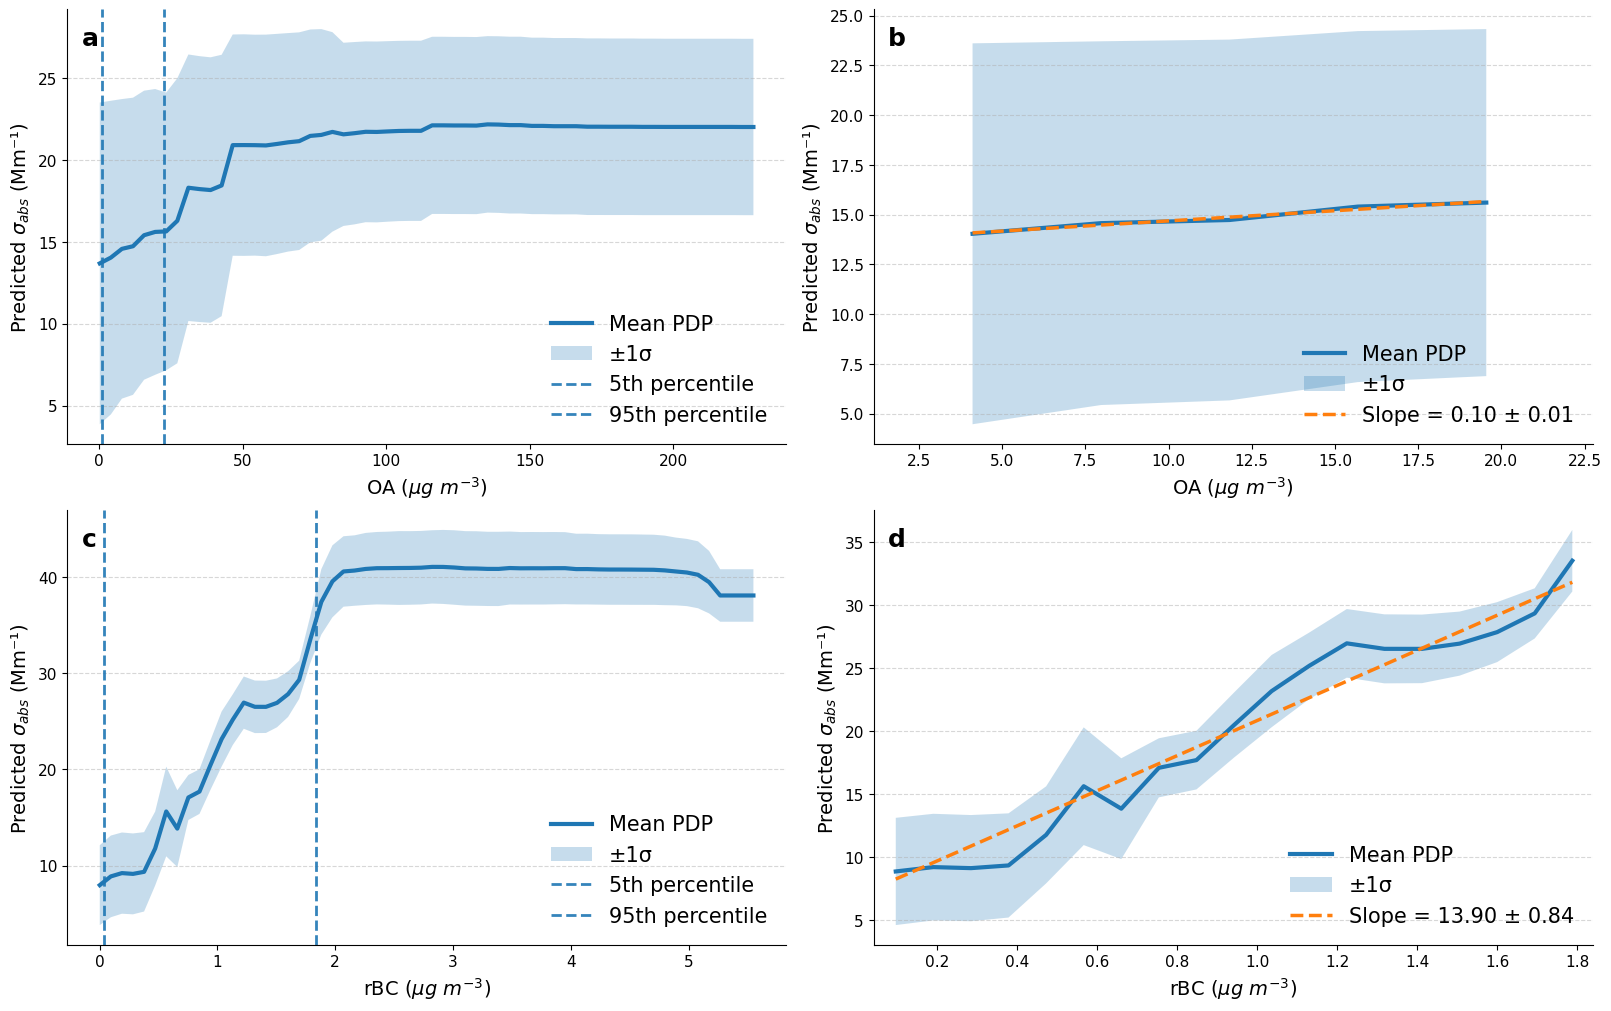

In [28]:
# Select the predictors to be analyzed through Partial Dependence
# Profiles (PDPs). Here, two contributors identified by
# the Random Forest model are examined in detail.
filtered_feat_importances = top_features[["OA", "rBC"]]

# Generate the publication-quality PDP figure for the selected
# predictors and retrieve the fitted regression parameters.
fig, axes, results = (
    plot_manual_pdp_top2_combined_figure(
        rf=rf,
        X_train=X_train,
        feat_importances=filtered_feat_importances,
        target_name=target_name,
    )
)

In [11]:
def run_random_forest_v2(
    df,
    target_variable,
    model_type="reduced",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
):
    """
    Train and evaluate a Random Forest model.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    target_variable : str
        Name of the variable to be predicted.
    model_type : {"full", "reduced"}, default="reduced"
        Feature set used for the model.
    test_size : float, default=0.2
        Fraction of the dataset used for testing.
    random_state : int, default=42
        Random seed.
    n_estimators : int, default=600
        Number of trees in the Random Forest.

    Returns
    -------
    top_features : pandas.Series
        Feature importance ranked in descending order.
    r2 : float
        Coefficient of determination.
    rmse : float
        Root Mean Square Error.
    features : pandas.DataFrame
        Predictor variables.
    X_train : pandas.DataFrame
        Training predictors.
    X_test : pandas.DataFrame
        Testing predictors.
    target_name : str
        Publication-style name of the predicted variable.
    """

    # Define the predictor sets used in the two Random Forest
    # configurations evaluated in this study.
    full_drop = [
        "Ext", "TSC_green", "TSC_blue", "TSC_red",
        "Flight", "ABS_PSAP", "DG", "AS", "AN"
    ]

    reduced_drop = full_drop + [
        "LAT", "LON", "ALT", "CO"
    ]

    drop_columns = {
        "full": full_drop,
        "reduced": reduced_drop,
    }

    # Build the predictor matrix while automatically excluding the
    # selected target variable.
    features = df.drop(
        columns=list(set(drop_columns[model_type] + [target_variable]))
    )

    # Convert optical coefficients from m⁻¹ to Mm⁻¹ to maintain
    # consistency with the units used throughout the manuscript.
    optical_targets = [
        "Ext",
        "TSC_blue",
        "TSC_green",
        "TSC_red",
        "ABS_PSAP",
    ]

    if target_variable in optical_targets:
        target = df[target_variable] * 1e6
    else:
        target = df[target_variable]

    # Retrieve the publication-style label associated with the selected
    # target variable.
    target_name = target_labels.get(target_variable, target_variable)

    # Split the observations into independent training and testing
    # subsets for model evaluation.
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        target,
        test_size=test_size,
        random_state=random_state,
    )

    # Train the Random Forest regression model.
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)

    # Evaluate the model performance using the independent test dataset.
    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Rank the predictor variables according to their relative importance
    # in the fitted Random Forest model.
    feature_importance = pd.Series(
        rf.feature_importances_,
        index=features.columns
    )

    return (
        rf,
        feature_importance,
        r2,
        rmse,
        features,
        X_train,
        X_test,
        target_name,
    )

In [12]:
def plot_rf_feature_importance_comparison(
    results,
    figsize=(8, 8),
    label_fs=12,
    tick_fs=11,
):

    import matplotlib.pyplot as plt
    import pandas as pd

    # --------------------------------------------------
    # Feature order (same for every model)
    # --------------------------------------------------
    feature_order = [
        "OA",
        "rBC",
        "SO4",
        "NH4",
        "NO3",
        "CO",
        "PM_coarse",
        "ALT",
        "LAT",
        "LON",
    ]

    # --------------------------------------------------
    # Consistent colors
    # --------------------------------------------------
    feature_colors = {
        "OA": "green",
        "rBC": "black",
        "SO4": "red",
        "NH4": "orange",
        "NO3": "navy",
        "CO": "mediumpurple",
        "PM_coarse": "blue",
        "ALT": "dimgray",
        "LAT": "gray",
        "LON": "silver",
    }
    # --------------------------------------------------
    # Collect feature importance from each model
    # --------------------------------------------------
    importance_list = []
    model_names = []

    for result in results:

        (
            rf,
            feature_importance,
            r2,
            rmse,
            features,
            X_train,
            X_test,
            target_name,
        ) = result

        # Reorder features
        feature_importance = (
            feature_importance
            .reindex(feature_order)
            .fillna(0)
        )

        importance_list.append(feature_importance)
        model_names.append(target_name)

    # --------------------------------------------------
    # Common x-axis limit
    # --------------------------------------------------
    max_importance = max(
        imp.max() for imp in importance_list
    ) * 1.10

    # --------------------------------------------------
    # Create figure
    # --------------------------------------------------
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True
    )

    panel_titles = [
        "(a) Scattering",
        "(b) Absorption",
        "(c) Extinction"
    ]

    # --------------------------------------------------
    # Plot each RF model
    # --------------------------------------------------
    for ax, imp, panel_title in zip(
        axes,
        importance_list,
        panel_titles
    ):

        colors = [
            feature_colors[f]
            for f in feature_order
        ]

        ax.bar(
            feature_order,
            imp.values,
            color=colors,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
        )

        ax.set_ylim(0, max_importance)

        ax.set_ylabel(
            "Importance",
            fontsize=label_fs
        )

        ax.set_title(
            panel_title,
            fontsize=label_fs,
            loc="left",
            fontweight="bold",
        )

        # Remove unnecessary borders
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Tick size
        ax.tick_params(
            axis="y",
            labelsize=tick_fs
        )

        # Group separators
        ax.axvline(
            4.5,
            color="0.5",
            ls="--",
            lw=1,
        )

        #ax.axvline(
        #    5.5,
        #    color="0.5",
        #    ls="--",
        #    lw=1,
        #)

        #ax.axvline(
        #    6.5,
        #    color="0.5",
        #    ls="--",
        #    lw=1,
        #)

        # Group labels
        ymax = max_importance * 1.01

        ax.text(
            2,
            ymax,
            "Mass composition",
            ha="center",
            va="top",
            fontsize=10,
        )

        #ax.text(
        #    5,
        #    ymax,
        #    "Tracer",
        #    ha="center",
        #    va="top",
        #    fontsize=10,
        #)

        #ax.text(
        #    6,
        #    ymax,
        #    "Coarse",
        #    ha="center",
        #    va="top",
        #    fontsize=10,
        #)

        ax.text(
            7,
            ymax,
            "Context",
            ha="center",
            va="top",
            fontsize=10,
        )
    # --------------------------------------------------
    # Bottom x-axis
    # --------------------------------------------------
    axes[-1].tick_params(
        axis="x",
        rotation=45,
        labelsize=tick_fs,
    )

    # Hide x labels from upper panels
    for ax in axes[:-1]:
        ax.tick_params(
            axis="x",
            labelbottom=False
        )

    axes[-1].set_xlabel(
        "Predictor",
        fontsize=label_fs
    )

    plt.tight_layout()

    return fig, axes

In [32]:
def plot_rf_feature_importance_comparison_v2(
    results,
    figsize=(11, 5),
    label_fs=12,
    tick_fs=11,
):

    import matplotlib.pyplot as plt

    # --------------------------------------------------
    # Feature order
    # --------------------------------------------------
    feature_order = [
        "OA",
        "rBC",
        "SO4",
        "NH4",
        "NO3",
        "PM_coarse",
    ]

    # --------------------------------------------------
    # Colors
    # --------------------------------------------------
    feature_colors = {
        "OA": "green",
        "rBC": "black",
        "SO4": "red",
        "NH4": "orange",
        "NO3": "navy",
        "CO": "mediumpurple",
        "PM_coarse": "blue",
        "ALT": "dimgray",
        "LAT": "gray",
        "LON": "silver",
    }

    # --------------------------------------------------
    # Collect importances
    # --------------------------------------------------
    importance_list = []

    for result in results:

        (
            rf,
            feature_importance,
            r2,
            rmse,
            features,
            X_train,
            X_test,
            target_name,
        ) = result

        feature_importance = (
            feature_importance
            .reindex(feature_order)
            .fillna(0)
        )

        importance_list.append(feature_importance)

    # --------------------------------------------------
    # Common x limit
    # --------------------------------------------------
    max_importance = (
        max(imp.max() for imp in importance_list) * 1.10
    )

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    panel_titles = [
        "(a) Scattering",
        "(b) Absorption",
        "(c) Extinction",
    ]

    y = range(len(feature_order))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    for i, (ax, imp, title) in enumerate(
        zip(axes, importance_list, panel_titles)
    ):

        colors = [
            feature_colors[f]
            for f in feature_order
        ]

        ax.barh(
            y,
            imp.values,
            color=colors,
            edgecolor="black",
            linewidth=0.8,
        )

        ax.set_xlim(0, max_importance)

        ax.set_title(
            title,
            loc="left",
            fontsize=label_fs,
            fontweight="bold",
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="x",
            labelsize=tick_fs,
        )

        # Hide predictor labels from all panels
        ax.set_yticks(y)
        ax.tick_params(
            axis="y",
            left=False,
            labelleft=False,
        )


        ax.set_xlabel(
            "Importance",
            fontsize=label_fs,
        )

    # Keep OA at the top
    axes[0].invert_yaxis()

    legend_handles = [
    Patch(
        facecolor=feature_colors[f],
        edgecolor="black",
        label=f
    )
    for f in feature_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.90, 0.5),
        frameon=False,
        fontsize=tick_fs,
        title="Predictor",
        title_fontsize=label_fs,
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])

    return fig, axes

(<Figure size 1100x500 with 3 Axes>,
 array([<Axes: title={'left': '(a) Scattering'}, xlabel='Importance'>,
        <Axes: title={'left': '(b) Absorption'}, xlabel='Importance'>,
        <Axes: title={'left': '(c) Extinction'}, xlabel='Importance'>],
       dtype=object))

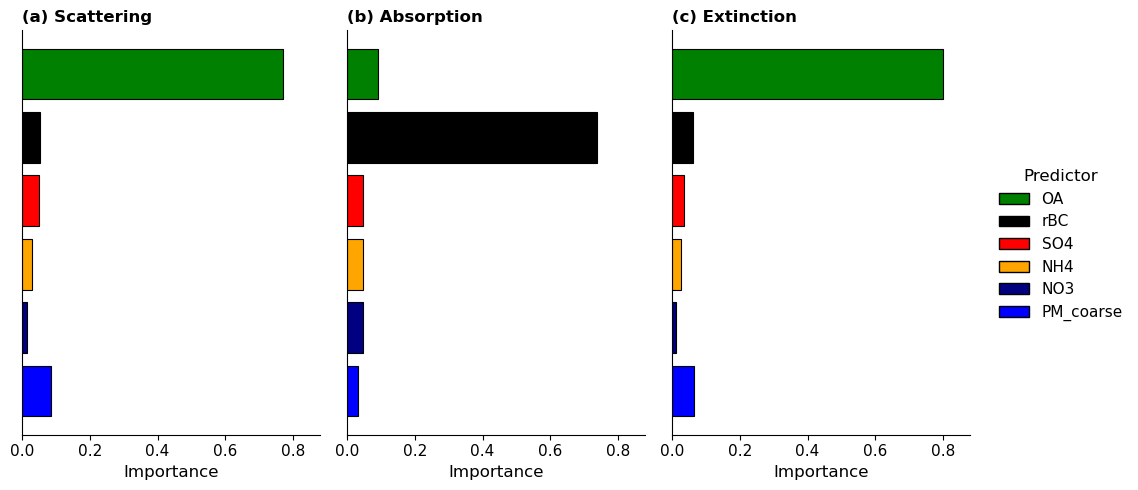

In [33]:
results = []

for target in [
    "TSC_green",
    "ABS_PSAP",
    "Ext",
]:

    results.append(
        run_random_forest_v2(
            df=df_clean,
            target_variable=target,
            model_type="reduced",
        )
    )

plot_rf_feature_importance_comparison_v2(results)